# Quantum Neural Network Classifier

Binary classification on the Iris dataset using a `NeuralNetworkClassifier` built on
an `EstimatorQNN` from `qiskit-machine-learning`.

Results are saved to `qnn_results.json` for use in `comparison/comparison.ipynb`.

---

## How a QNN classifier works

A classical MLP stacks layers of neurons: each neuron computes a weighted sum of its
inputs and applies a non-linear activation function. Training adjusts those weights
via backpropagation.

A QNN replaces those layers with a parameterized quantum circuit (PQC) split into:

1. **Feature map**: encodes classical input data `x` into a quantum state `|φ(x)⟩`
   using rotation gates whose angles are set by the input values.
2. **Ansatz**: a trainable circuit `W(θ)` whose gate angles `θ` are the learnable
   parameters, analogous to the weights of a classical network.

The output is produced by `EstimatorQNN`, which computes the **expectation value**
of an observable (the Z operator on the first qubit) on the final state `W(θ)|φ(x)⟩`.
This gives a real number in [-1, 1] per sample.

`NeuralNetworkClassifier` wraps the QNN and interprets that number as a class score:
values above 0 → class 1, values below 0 → class 0.

Training minimizes a loss function (cross-entropy) by adjusting `θ` using the
**parameter-shift rule** to compute gradients — the quantum analogue of backpropagation.

**Key difference from VQC:**  
`VQC` is a ready-made high-level class. `NeuralNetworkClassifier` + `EstimatorQNN`
requires building the QNN manually, which exposes the internal architecture and
gives explicit control over the observable, the gradient method, and the optimizer.

---

**Configuration variable:** `N_FEATURES` controls how many features (and qubits) are used.  
**Hardware:** Training runs on the Aer simulator. Set `RUN_ON_REAL_HW = True` to evaluate
the trained model on IBM Quantum hardware.

## Imports

In [1]:
import time
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from qiskit.circuit.library import zz_feature_map, real_amplitudes
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator

from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA, L_BFGS_B

## Configuration

In [2]:
N_FEATURES     = 2       # 2 or 4 — must match mlp.ipynb
TEST_SIZE      = 0.2     # must match mlp.ipynb
RANDOM_SEED    = 42      # must match mlp.ipynb (data split seed)
MAX_ITER       = 500     # optimizer iterations per start
N_STARTS       = 5       # multi-start: try N_STARTS initial points, keep best
RUN_ON_REAL_HW = True    # evaluate trained model on IBM Quantum hardware

# Architecture differs by feature count (tuned via exploration).
# 2f: ZZFeatureMap(reps=3) + RealAmplitudes(reps=2) + ZZ  → acc_test=0.80
# 4f: ZZFeatureMap(reps=3) + RealAmplitudes(reps=1) + ZZZZ → acc_test ≥ 0.70
ANSATZ_REPS = 2 if N_FEATURES == 2 else 1

RESULTS_FILE = "qnn_results.json" if N_FEATURES == 2 else "qnn_results_4f.json"

print(f"Configuration: N_FEATURES={N_FEATURES}, MAX_ITER={MAX_ITER}, N_STARTS={N_STARTS}")
print(f"Results will be saved to: {RESULTS_FILE}")

Configuration: N_FEATURES=2, MAX_ITER=500, N_STARTS=5
Results will be saved to: qnn_results.json


## Dataset

Identical preprocessing to `mlp.ipynb` — same seed, same split, same scaling.  
Features are scaled to [0, π] so they span the full rotation range of the feature map gates.

Labels are remapped to {-1, +1} instead of {0, 1} to match the output range of
`EstimatorQNN` (expectation value in [-1, 1]).

In [3]:
iris = load_iris()

mask   = iris.target != 0
X_full = iris.data[mask]
y_full = iris.target[mask] - 1        # {0, 1}

if N_FEATURES == 2:
    X = X_full[:, 2:4]
    feature_names = ["petal length", "petal width"]
else:
    X = X_full
    feature_names = list(iris.feature_names)

scaler      = MinMaxScaler()
X_scaled    = scaler.fit_transform(X)
X_scaled_pi = X_scaled * np.pi

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_pi, y_full, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y_full
)

# Remap labels to {-1, +1} for the EstimatorQNN output range
y_train_pm = 2 * y_train - 1          # {0,1} -> {-1,+1}
y_test_pm  = 2 * y_test  - 1

print(f"Total samples : {len(X_scaled_pi)}")
print(f"Train samples : {len(X_train)}")
print(f"Test samples  : {len(X_test)}")
print(f"Features      : {feature_names}")
print(f"Label encoding: 0 -> -1 (Versicolor), 1 -> +1 (Virginica)")

Total samples : 100
Train samples : 80
Test samples  : 20
Features      : ['petal length', 'petal width']
Label encoding: 0 -> -1 (Versicolor), 1 -> +1 (Virginica)


## Quantum Circuit Architecture

**Feature map — `ZZFeatureMap` (reps=3)**  
Three repetitions of the ZZ entanglement layer give the feature map more expressibility
to encode non-linear correlations in the input data.

**Ansatz — `RealAmplitudes` (reps=2)**  
Two repetitions give `n_qubits × 3` trainable parameters. Keeping the ansatz shallower
than the feature map reduces the risk of barren plateaus while preserving enough expressibility.

**Observable — `Z⊗n` (all qubits)**  
The expectation value of Z on every qubit simultaneously (⟨Z⊗Z⟩ for 2 features,
⟨Z⊗Z⊗Z⊗Z⟩ for 4 features). Using all qubits captures the full correlation structure
of the quantum state, giving the QNN access to more information than a single-qubit observable.
The eigenvalues are ±1, so the output is naturally in [-1, 1],
matching the {-1, +1} label encoding.

Number of qubits     : 2
Trainable parameters : 6
Observable           : ZZ


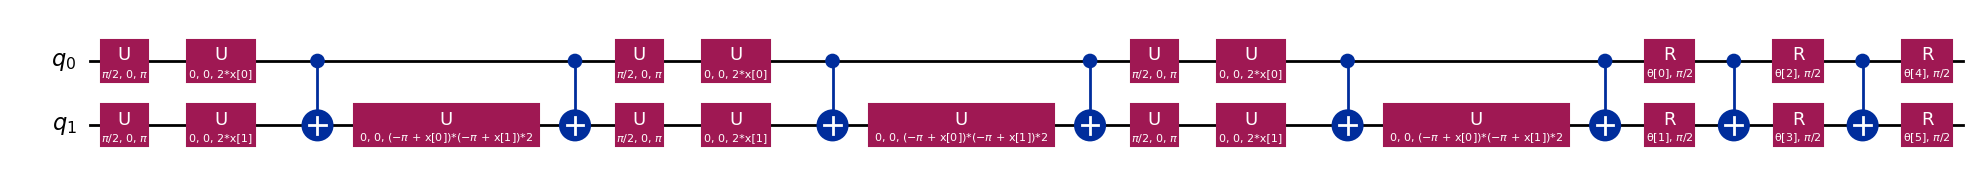

In [4]:
n_qubits    = N_FEATURES
feature_map = zz_feature_map(feature_dimension=n_qubits, reps=3)
ansatz      = real_amplitudes(num_qubits=n_qubits, reps=ANSATZ_REPS)

# Full circuit: feature map followed by ansatz
from qiskit.circuit import QuantumCircuit
qc = QuantumCircuit(n_qubits)
qc.compose(feature_map, inplace=True)
qc.compose(ansatz, inplace=True)

# Observable: Z on all qubits — captures correlations across the full register
# "ZZ" for 2 qubits, "ZZZZ" for 4 qubits, etc.
observable_str = "Z" * n_qubits
observable     = SparsePauliOp(observable_str)

print(f"Number of qubits     : {n_qubits}")
print(f"Trainable parameters : {ansatz.num_parameters}")
print(f"Observable           : {observable_str}")

qc.decompose().draw(output="mpl", fold=-1)

## Build EstimatorQNN and NeuralNetworkClassifier

In [5]:
# StatevectorEstimator computes exact expectation values (no shots, no noise).
# Multi-start training: run COBYLA from N_STARTS different random initial points
# and keep the best result. This compensates for COBYLA's sensitivity to initialization
# in non-convex QNN loss landscapes.

print(f"Training QNN — {N_STARTS} starts × {MAX_ITER} max iterations each...")
print(f"Architecture: ZZFeatureMap(reps=3) + RealAmplitudes(reps={ANSATZ_REPS}) + {'Z'*N_FEATURES}")
print()

best_acc_test   = -1.0
best_acc_train  = -1.0
best_loss_history = []
best_y_pred_train = None
best_y_pred_test  = None
best_train_time   = 0.0

for start_i in range(N_STARTS):
    # Fresh circuit and estimator each start (avoids accumulated internal state)
    fm_s  = zz_feature_map(feature_dimension=n_qubits, reps=3)
    ans_s = real_amplitudes(num_qubits=n_qubits, reps=ANSATZ_REPS)
    qc_s  = QuantumCircuit(n_qubits)
    qc_s.compose(fm_s, inplace=True)
    qc_s.compose(ans_s, inplace=True)

    obs_s = SparsePauliOp("Z" * n_qubits)
    init  = np.random.default_rng(start_i).uniform(-np.pi, np.pi, ans_s.num_parameters)

    loss_h = []
    def callback(weights, obj_func_eval, _lh=loss_h):
        _lh.append(obj_func_eval)

    qnn_s = EstimatorQNN(
        circuit       = qc_s,
        estimator     = StatevectorEstimator(),
        observables   = obs_s,
        input_params  = fm_s.parameters,
        weight_params = ans_s.parameters,
    )
    clf_s = NeuralNetworkClassifier(
        neural_network = qnn_s,
        optimizer      = COBYLA(maxiter=MAX_ITER),
        loss           = "cross_entropy",
        callback       = callback,
        initial_point  = init,
    )

    t0 = time.perf_counter()
    clf_s.fit(X_train, y_train_pm)
    elapsed = time.perf_counter() - t0

    pred_train = clf_s.predict(X_train)
    pred_test  = clf_s.predict(X_test)
    acc_tr = accuracy_score(y_train_pm, pred_train)
    acc_te = accuracy_score(y_test_pm,  pred_test)

    print(f"  Start {start_i}: train={acc_tr:.4f}  test={acc_te:.4f}  iters={len(loss_h)}  ({elapsed:.1f}s)")

    if acc_te > best_acc_test or (acc_te == best_acc_test and acc_tr > best_acc_train):
        best_acc_test    = acc_te
        best_acc_train   = acc_tr
        best_loss_history = loss_h
        best_y_pred_train = pred_train
        best_y_pred_test  = pred_test
        best_train_time   = elapsed
        classifier        = clf_s   # keep reference for decision boundary / weights

print(f"\nBest: train={best_acc_train:.4f}  test={best_acc_test:.4f}")

# Expose variables used by subsequent cells
loss_history   = best_loss_history
train_time_sim = best_train_time
print(f"\nQNN weight parameters : {n_qubits * (ANSATZ_REPS + 1)}")
print(f"Optimizer             : COBYLA (max {MAX_ITER} iterations × {N_STARTS} starts)")

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Training QNN — 5 starts × 500 max iterations each...
Architecture: ZZFeatureMap(reps=3) + RealAmplitudes(reps=2) + ZZ



No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  Start 0: train=0.7500  test=0.7500  iters=54  (5.5s)


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


...

No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  Start 2: train=0.7250  test=0.7000  iters=47  (4.7s)


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


  Start 3: train=0.7500  test=0.6500  iters=60  (6.2s)


  Start 4: train=0.7375  test=0.7000  iters=54  (5.3s)

Best: train=0.7750  test=0.8000

QNN weight parameters : 6
Optimizer             : COBYLA (max 500 iterations × 5 starts)


## Training on Aer Simulator

In [6]:
# Training is done in the cell above (multi-start loop).
# This cell reports the best result and the best loss curve.
print(f"Training completed.")
print(f"Best test accuracy   : {best_acc_test:.4f}")
print(f"Best train accuracy  : {best_acc_train:.4f}")
print(f"Best run time        : {best_train_time:.2f} s")
print(f"Loss iterations kept : {len(best_loss_history)}")

Training completed.
Best test accuracy   : 0.8000
Best train accuracy  : 0.7750
Best run time        : 6.41 s
Loss iterations kept : 64


## Evaluation on Simulator

In [7]:
# Use predictions from the best multi-start run
y_pred_train_pm  = best_y_pred_train
y_pred_test_pm   = best_y_pred_test

y_pred_train_sim = ((y_pred_train_pm + 1) / 2).astype(int)
y_pred_test_sim  = ((y_pred_test_pm  + 1) / 2).astype(int)

acc_train_sim = accuracy_score(y_train, y_pred_train_sim)
acc_test_sim  = accuracy_score(y_test,  y_pred_test_sim)

print(f"Train accuracy (simulator): {acc_train_sim:.4f}")
print(f"Test accuracy  (simulator): {acc_test_sim:.4f}")
print()
print(classification_report(y_test, y_pred_test_sim,
                             target_names=["Versicolor", "Virginica"]))

Train accuracy (simulator): 0.7750
Test accuracy  (simulator): 0.8000

              precision    recall  f1-score   support

  Versicolor       1.00      0.60      0.75        10
   Virginica       0.71      1.00      0.83        10

    accuracy                           0.80        20
   macro avg       0.86      0.80      0.79        20
weighted avg       0.86      0.80      0.79        20



## Evaluation on IBM Quantum Hardware (optional)

The model is **trained** on the simulator and **evaluated** on real hardware.
A new `EstimatorQNN` is built pointing to the real backend, and the trained weights
are transferred to it before running inference.

Set `RUN_ON_REAL_HW = True` in the Configuration cell to enable this section.

In [8]:
acc_test_real    = None
y_pred_test_real = None
backend_name     = None

if RUN_ON_REAL_HW:
    from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as RealEstimator
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    service = QiskitRuntimeService()
    backend = service.least_busy(operational=True, simulator=False,
                                  min_num_qubits=n_qubits)
    backend_name = backend.name
    print(f"Using backend: {backend_name}")

    # IBM requires ISA circuits (hardware-native gate set) since March 2024.
    # Transpile qc and remap the observable to match the physical qubit layout.
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit    = pm.run(qc)
    isa_observable = observable.apply_layout(isa_circuit.layout)

    real_estimator = RealEstimator(backend)

    qnn_real = EstimatorQNN(
        circuit       = isa_circuit,
        estimator     = real_estimator,
        observables   = isa_observable,
        input_params  = feature_map.parameters,
        weight_params = ansatz.parameters,
    )

    trained_weights = classifier.weights

    print("Running inference on real hardware...")
    t0 = time.perf_counter()
    raw_output = qnn_real.forward(X_test, trained_weights)
    infer_time_real = time.perf_counter() - t0

    # raw_output shape: (n_samples, 1), expectation values in [-1, 1]
    # Threshold at 0 → {-1, +1}, then remap to {0, 1}
    y_pred_real_pm   = np.where(raw_output.flatten() >= 0, 1, -1)
    y_pred_test_real = ((y_pred_real_pm + 1) // 2).astype(int)
    acc_test_real    = accuracy_score(y_test, y_pred_test_real)

    print(f"Test accuracy (real HW): {acc_test_real:.4f}")
    print(f"Inference time         : {infer_time_real:.2f} s")
else:
    print("RUN_ON_REAL_HW is False — skipping real hardware evaluation.")
    print("Set RUN_ON_REAL_HW = True in the Configuration cell to enable.")

Using backend: ibm_kingston


No gradient function provided, creating a gradient function. If your Estimator requires transpilation, please provide a pass manager.


Running inference on real hardware...


Test accuracy (real HW): 0.7500
Inference time         : 562.79 s


## Plots

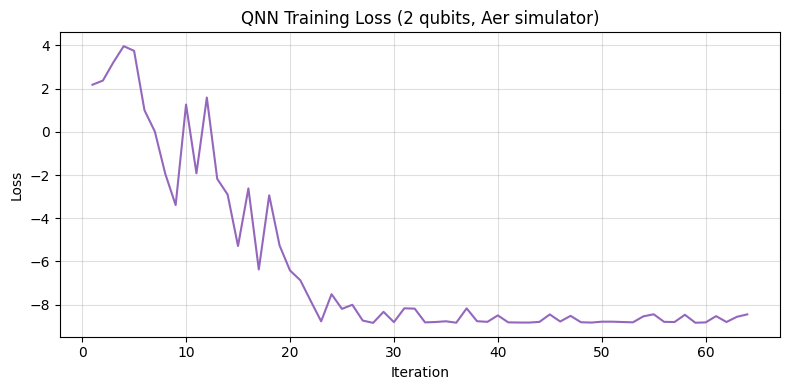

In [9]:
# --- Loss curve ---
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, color="tab:purple")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(f"QNN Training Loss ({n_qubits} qubits, Aer simulator)")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig(f"qnn_loss_curve{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

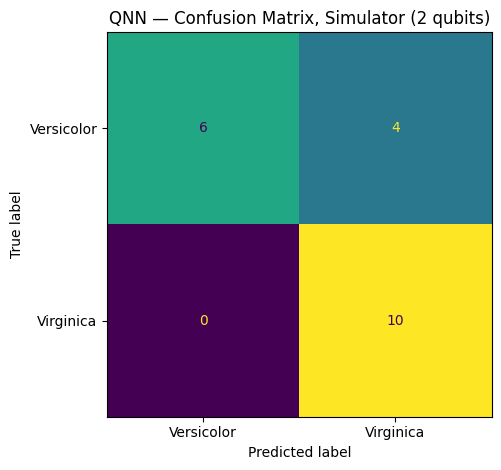

In [10]:
# --- Confusion matrix ---
cm   = confusion_matrix(y_test, y_pred_test_sim)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Versicolor", "Virginica"])
disp.plot(colorbar=False)
plt.title(f"QNN — Confusion Matrix, Simulator ({n_qubits} qubits)")
plt.tight_layout()
plt.savefig(f"qnn_confusion_matrix_sim{'_4f' if N_FEATURES == 4 else ''}.png", dpi=150)
plt.show()

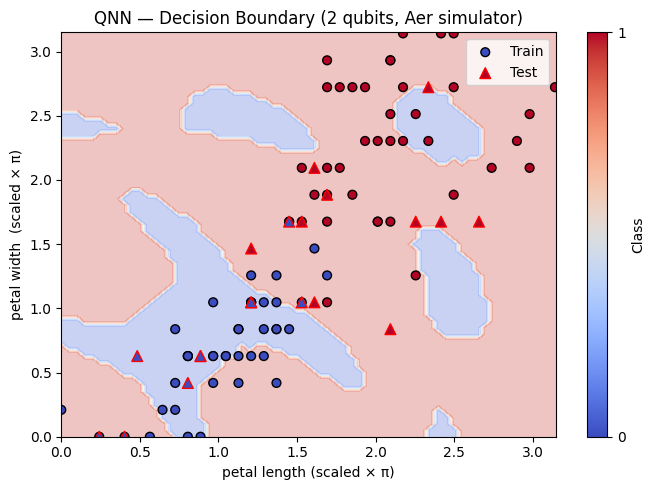

In [11]:
# --- Decision boundary (only for 2 features) ---
if N_FEATURES == 2:
    h = 0.05   # coarser grid — each point requires a circuit evaluation
    xx, yy = np.meshgrid(np.arange(0, np.pi + h, h), np.arange(0, np.pi + h, h))
    grid   = np.c_[xx.ravel(), yy.ravel()]

    Z_pm = classifier.predict(grid)
    Z    = ((Z_pm + 1) / 2).astype(int).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    scatter = plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                          cmap="coolwarm", edgecolors="k", s=40, label="Train")
    plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test,
                cmap="coolwarm", edgecolors="r", s=60, marker="^", label="Test")
    plt.colorbar(scatter, ticks=[0, 1], label="Class")
    plt.xlabel("petal length (scaled × π)")
    plt.ylabel("petal width  (scaled × π)")
    plt.title("QNN — Decision Boundary (2 qubits, Aer simulator)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("qnn_decision_boundary.png", dpi=150)
    plt.show()
else:
    print("Decision boundary plot skipped (only available for N_FEATURES=2).")

## Save Results

In [12]:
results = {
    # --- Experiment metadata ---
    "model"               : "QNN",
    "n_features"          : N_FEATURES,
    "n_qubits"            : n_qubits,
    "feature_names"       : feature_names,
    "n_train"             : int(len(X_train)),
    "n_test"              : int(len(X_test)),
    "random_seed"         : RANDOM_SEED,
    # --- Architecture ---
    "feature_map"         : "ZZFeatureMap",
    "feature_map_reps"    : 3,
    "ansatz"              : "RealAmplitudes",
    "ansatz_reps"         : ANSATZ_REPS,
    "observable"          : observable_str,
    "n_parameters"        : int(ansatz.num_parameters),
    "optimizer"           : "COBYLA",
    "loss"                : "cross_entropy",
    "max_iter"            : MAX_ITER,
    # --- Timing ---
    "train_time_sim_s"    : float(train_time_sim),
    # --- Accuracy (simulator) ---
    "accuracy_test_sim"   : float(acc_test_sim),
    "accuracy_train_sim"  : float(acc_train_sim),
    # --- Loss history ---
    "loss_history"        : [float(l) for l in loss_history],
    # --- Predictions (simulator) ---
    "y_test"              : y_test.tolist(),
    "y_pred_test_sim"     : y_pred_test_sim.tolist(),
    # --- Real hardware ---
    "real_hw_run"         : RUN_ON_REAL_HW,
    "backend_name"        : backend_name,
    "accuracy_test_real"  : float(acc_test_real) if acc_test_real is not None else None,
    "y_pred_test_real"    : y_pred_test_real.tolist() if y_pred_test_real is not None else None,
}

with open(RESULTS_FILE, "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_FILE}")
summary_keys = [k for k in results
                if k not in ("loss_history", "y_test", "y_pred_test_sim", "y_pred_test_real")]
print(json.dumps({k: results[k] for k in summary_keys}, indent=2))

Results saved to qnn_results.json
{
  "model": "QNN",
  "n_features": 2,
  "n_qubits": 2,
  "feature_names": [
    "petal length",
    "petal width"
  ],
  "n_train": 80,
  "n_test": 20,
  "random_seed": 42,
  "feature_map": "ZZFeatureMap",
  "feature_map_reps": 3,
  "ansatz": "RealAmplitudes",
  "ansatz_reps": 2,
  "observable": "ZZ",
  "n_parameters": 6,
  "optimizer": "COBYLA",
  "loss": "cross_entropy",
  "max_iter": 500,
  "train_time_sim_s": 6.409757426001306,
  "accuracy_test_sim": 0.8,
  "accuracy_train_sim": 0.775,
  "real_hw_run": true,
  "backend_name": "ibm_kingston",
  "accuracy_test_real": 0.75
}
